# Logistic Regression for Binary Classification

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

## Data Understanding

In [2]:
df = pd.read_csv('Loan_Predication.csv')

In [3]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


## Check Duplicates

In [5]:

df[df.duplicated()]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status


## Data Cleaning and Hanling Missing Values

In [6]:
df.drop("Loan_ID", axis=1, inplace=True)

In [7]:
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             614 non-null    object 
 1   Married            614 non-null    object 
 2   Dependents         614 non-null    object 
 3   Education          614 non-null    object 
 4   Self_Employed      614 non-null    object 
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         614 non-null    float64
 8   Loan_Amount_Term   614 non-null    float64
 9   Credit_History     614 non-null    float64
 10  Property_Area      614 non-null    object 
 11  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 57.7+ KB


In [9]:
df['Dependents'] = df['Dependents'].replace('3+', 3).astype(int)

## Feature engineering

In [10]:
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y,5849.0
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0


## Data Encoding

In [11]:
print(df['Gender'].unique())
print(df['Married'].unique())
print(df['Education'].unique())
print(df['Self_Employed'].unique())
print(df['Property_Area'].unique())

['Male' 'Female']
['No' 'Yes']
['Graduate' 'Not Graduate']
['No' 'Yes']
['Urban' 'Rural' 'Semiurban']


In [12]:
cat_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [13]:
df.head()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Total_Income,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0,5849,0.0,128.0,360.0,1.0,Y,5849.0,True,False,False,False,False,True
1,1,4583,1508.0,128.0,360.0,1.0,N,6091.0,True,True,False,False,False,False
2,0,3000,0.0,66.0,360.0,1.0,Y,3000.0,True,True,False,True,False,True
3,0,2583,2358.0,120.0,360.0,1.0,Y,4941.0,True,True,True,False,False,True
4,0,6000,0.0,141.0,360.0,1.0,Y,6000.0,True,False,False,False,False,True


In [14]:
str_cols = ['Gender_Male', 'Married_Yes', 'Education_Not Graduate', 'Self_Employed_Yes', 'Property_Area_Semiurban', 'Property_Area_Urban']
for col in str_cols:
    df[col] = df[col].astype(int)

In [15]:
df.head()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Total_Income,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0,5849,0.0,128.0,360.0,1.0,Y,5849.0,1,0,0,0,0,1
1,1,4583,1508.0,128.0,360.0,1.0,N,6091.0,1,1,0,0,0,0
2,0,3000,0.0,66.0,360.0,1.0,Y,3000.0,1,1,0,1,0,1
3,0,2583,2358.0,120.0,360.0,1.0,Y,4941.0,1,1,1,0,0,1
4,0,6000,0.0,141.0,360.0,1.0,Y,6000.0,1,0,0,0,0,1


In [16]:
df['Loan_Status'] = df['Loan_Status'].map({'Y':1, 'N':0})

## Model Training

We prepare the dataset for modeling by selecting relevant features and splitting the data into training and testing sets.

In [17]:
x = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

x_train, x_test, y_train, y_test = train_test_split(x, y, stratify=y, test_size=0.3, random_state=42)

In [18]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

We train different models such as:

- Logistic Regression L2 (regular).
- Logistic Regression L1.
- Logistic Regression with GridSearchCV.

to predict Loan Status.

Logistic Regression L2 (regular).

In [19]:
lr_l2 = LogisticRegression(penalty='l2', random_state=42, max_iter=1000)
lr_l2.fit(x_train, y_train)
y_pred_l2 = lr_l2.predict(x_test)

train_acc_l2 = accuracy_score(y_train, lr_l2.predict(x_train))
test_acc_l2 = accuracy_score(y_test, lr_l2.predict(x_test))
auc_l2 = roc_auc_score(y_test, lr_l2.predict_proba(x_test)[:, 1])

print("LR L2 - Test Accuracy:", accuracy_score(y_test, y_pred_l2))
print(confusion_matrix(y_test, y_pred_l2))
print(classification_report(y_test, y_pred_l2))

LR L2 - Test Accuracy: 0.8486486486486486
[[ 33  25]
 [  3 124]]
              precision    recall  f1-score   support

           0       0.92      0.57      0.70        58
           1       0.83      0.98      0.90       127

    accuracy                           0.85       185
   macro avg       0.87      0.77      0.80       185
weighted avg       0.86      0.85      0.84       185



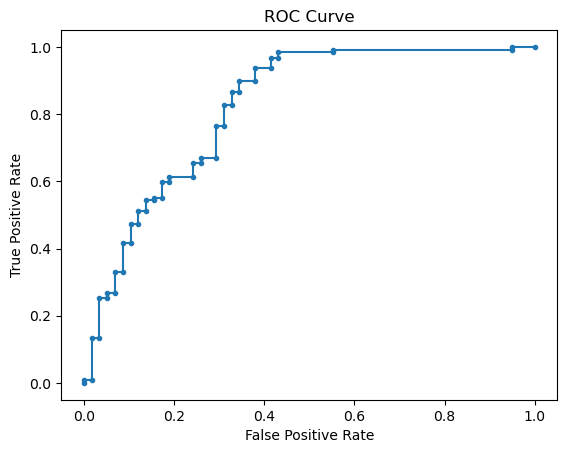

AUC Score: 0.82


In [20]:
y_prob = lr_l2.predict_proba(x_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, marker='.')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

auc_score = roc_auc_score(y_test, y_prob)
print(f"AUC Score: {auc_score:.2f}")

Logistic Regression L1.

In [21]:
lr_l1 = LogisticRegression(penalty='l1', solver='liblinear', random_state=42, max_iter=1000)
lr_l1.fit(x_train, y_train)
y_pred_l1 = lr_l1.predict(x_test)

train_acc_l1 = accuracy_score(y_train, lr_l1.predict(x_train))
test_acc_l1 = accuracy_score(y_test, lr_l1.predict(x_test))
auc_l1 = roc_auc_score(y_test, lr_l1.predict_proba(x_test)[:, 1])

print("LR L1 - Test Accuracy:", accuracy_score(y_test, y_pred_l1))
print(confusion_matrix(y_test, y_pred_l1))
print(classification_report(y_test, y_pred_l1))

LR L1 - Test Accuracy: 0.8486486486486486
[[ 33  25]
 [  3 124]]
              precision    recall  f1-score   support

           0       0.92      0.57      0.70        58
           1       0.83      0.98      0.90       127

    accuracy                           0.85       185
   macro avg       0.87      0.77      0.80       185
weighted avg       0.86      0.85      0.84       185



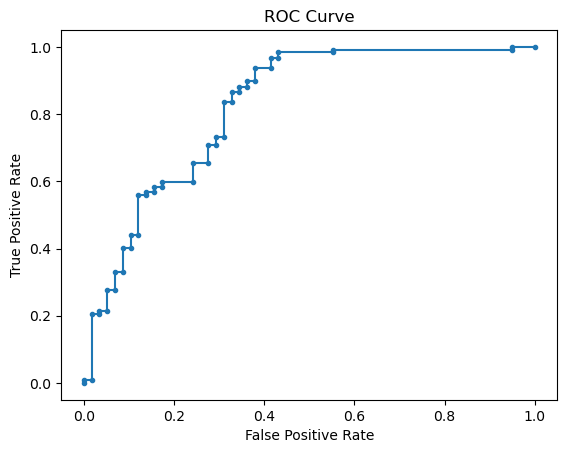

AUC Score: 0.82


In [22]:
y_prob = lr_l1.predict_proba(x_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, marker='.')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

auc_score = roc_auc_score(y_test, y_prob)
print(f"AUC Score: {auc_score:.2f}")

Logistic Regression with GridSearchCV.

In [23]:
param_grid_lr = {'C': [0.1, 1, 10], 'penalty': ['l1', 'l2'], 'solver': ['liblinear'], 'max_iter': [1000]}
grid_lr = GridSearchCV(LogisticRegression(random_state=42), param_grid_lr, cv=5, scoring='accuracy')
grid_lr.fit(x_train, y_train)
best_lr = grid_lr.best_estimator_
y_pred_best_lr = best_lr.predict(x_test)

train_acc_best_lr = accuracy_score(y_train, best_lr.predict(x_train))
test_acc_best_lr = accuracy_score(y_test, best_lr.predict(x_test))
auc_best_lr = roc_auc_score(y_test, best_lr.predict_proba(x_test)[:, 1])

print("Best LR - Test Accuracy:", accuracy_score(y_test, y_pred_best_lr))
print("Best Params:", grid_lr.best_params_)

Best LR - Test Accuracy: 0.8486486486486486
Best Params: {'C': 0.1, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}


Models Comparison

In [24]:
results = pd.DataFrame({
    'Model': ['LR L1', 'LR L2', 'Best LR'],
    'Train Acc': [train_acc_l1, train_acc_l2, train_acc_best_lr,],
    'Test Acc': [test_acc_l1, test_acc_l2, test_acc_best_lr],
    'AUC': [auc_l1, auc_l2, auc_best_lr]
})
results

,Model,Train Acc,Test Acc,AUC
0,LR L1,0.794872,0.848649,0.823378
1,LR L2,0.794872,0.848649,0.822835
2,Best LR,0.792541,0.848649,0.826161


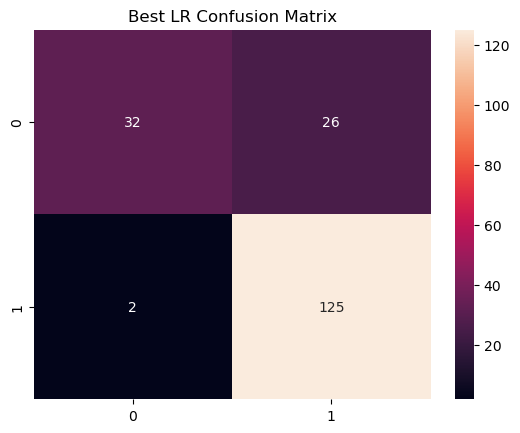

In [26]:
cm_best_lr = confusion_matrix(y_test, y_pred_best_lr)
sns.heatmap(cm_best_lr, annot=True, fmt='d')
plt.title('Best LR Confusion Matrix')
plt.show()

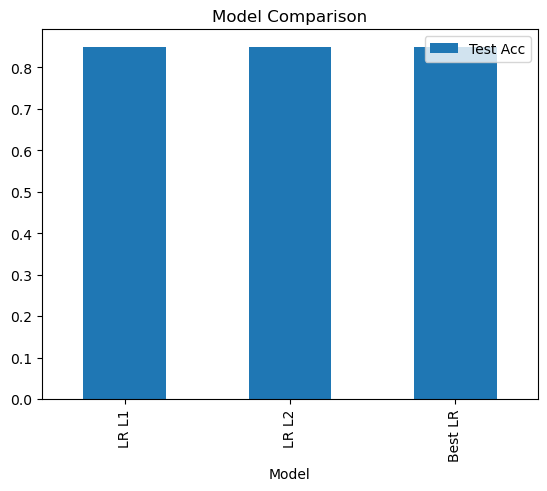

In [27]:
results.plot(x='Model', y='Test Acc', kind='bar')
plt.title('Model Comparison')
plt.show()

results = results.round(4)